In [30]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from cooling import get_t_cool_n, get_t_cool_cgs, load_cooling_table
import astropy.units as u
import astropy.constants as C

# Load cooling table
load_cooling_table("/viper/ptmp/ferhi/cooling_tables/gnat-sternberg.cooling_1Z")

# Unit conversions
pc   = 3.086e18
Myr  = 3.15576e13
Msun = 1.989e33
km   = 1e5
mbar = 9.8e-25


class FallingCloud(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, profile = 'MW'):
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        if profile == 'MW':
            self.profile_n = lambda x: 0.0001      # cm^-3
            self.profile_g = lambda x: 1e-8     # (same units used elsewhere)
            self.profile_T = lambda x: 1e6      # K
            
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s')
        Lturb = r_cl0
        f_A = 0.23
        self.tgrow0 = 12 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25)
        print("This is tgrow: ", self.tgrow0)

    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d):
        return self.r_cl0 * (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)


    def integrate(self,stop_value, f_KH = 5., alpha = 5/6., verbose = 1, stop_mode = 'time'):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                             'time' for stopping time in Myr
                             'height' for falling until height (in kpc) above disk
                             'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """
        def _odefun(t, y):
            # separate variables        
            z, v, m = y
            z_kpc = z / u.kpc.to('m') 
            rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)
            g = -self.profile_g(z_kpc) * 1e-2  
            C0 = 0.6 # drag coefficient
            rcl = self.rcl(z_kpc) 
            rcl_m = rcl * u.parsec.to('m')
            Across = np.pi * rcl_m**2 


            r_pc_to_kpc = u.parsec.to('kpc')
            w_KH = max(1, f_KH* np.sqrt(self.chi(z_kpc)) *
              (self.r_cl0 * r_pc_to_kpc) /
              abs(self.d0 - z_kpc))


            tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s')
            vrat = 150. / min(abs(v)/1000., 150.) 
            tcoolrat = tcool_cl / self.tcool0
            mrat = m  / (self.mass0 * u.Msun.to('kg'))
            rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

            tgrow = w_KH * self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)

            dzdt = v
            dvdt = g - (v / tgrow) + 0.5 * rho_h * v**2 * C0 * Across / m 
            dmdt = m / tgrow
            r = [dzdt, dvdt, dmdt]

            return np.array(r) 
        
        y0 = (self.d0 * u.kpc.to('m'), 1e-3, self.mass0 * u.M_sun.to('kg'))

        tol = (1e-5 * u.kpc.to('m'), 1e-5, 1e-5 * self.mass0* u.M_sun.to('kg'))
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o)
        if verbose > 0:
            print(r['message'])

        self.integration_result = r
        return r
    
    def vTgrow(self, z,v,m, alpha=5/6):
        z_kpc = z / u.kpc.to('m')
        w_KH = np.maximum(1, 5*  np.sqrt(self.chi(z_kpc)) *
            (self.r_cl0 * u.parsec.to('kpc')) /
            abs(self.d0 - z_kpc))


        tcool_cl = get_t_cool_n( self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s')
        vrat = 150. / np.minimum(abs(v)/1000., 150.) 
        tcoolrat = tcool_cl / self.tcool0
        mrat = m  / (self.mass0 * u.M_sun.to('kg'))
        rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

        tgrow =  w_KH * self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)
        print("this is g: " , self.profile_g)
        return self.profile_g(z_kpc) * tgrow / 1e2
    
    def vTdrag(self, z,m):
        z_kpc = z / u.kpc.to('m')
        rcl = self.rcl(z_kpc) * u.pc.to('m')  # Also fix: use z_kpc
        rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)  # Convert to kg/m³
        #return np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * rcl**2 * 0.6))
        return np.ones_like(z) * np.sqrt(2 * rcl * self.chi(z_kpc) * self.profile_g(z_kpc) * 1e-2 / ( 0.6))


    def plot_trajectory(self):
        assert self.integration_result is not None, "Have to run integrate first."
        r = self.integration_result
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, r['y'][0] / u.kpc.to('m'),'-')
        plt.xlabel("t")
        plt.ylabel("z")
        plt.figure()
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(1,1e3)
        plt.plot(r['t'] / Myr, self.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.yscale('log')
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("Mass (Msun)")


    def plot_timescales(self):
        r = self.integration_result
        time = r['t'][::-1] / u.Myr.to('s')
        plt.plot(time, self.vTgrow(r['y'][0], r['y'][1], r['y'][2]))
        plt.axhline(4, c='black', alpha = 0.5)
        plt.xlabel("t (Myr)")
        plt.ylabel("tgrow / tcc")

This is tgrow:  52.55685124540582
A termination event occurred.
this is g:  <function FallingCloud.__init__.<locals>.<lambda> at 0x146d65560180>


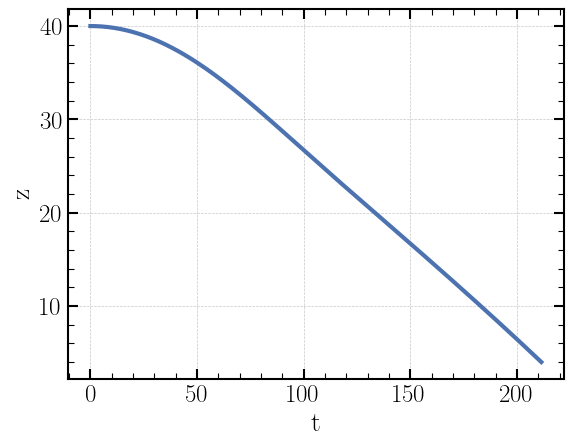

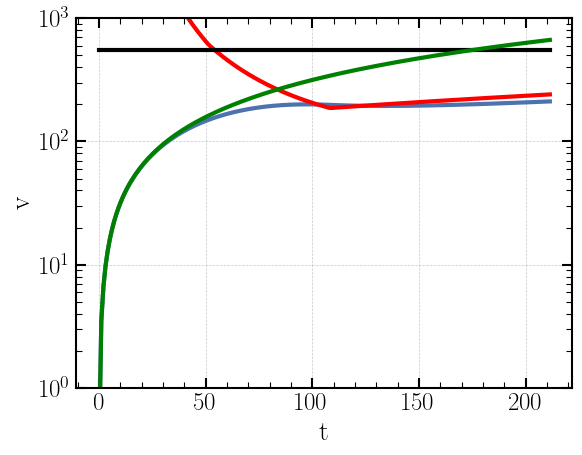

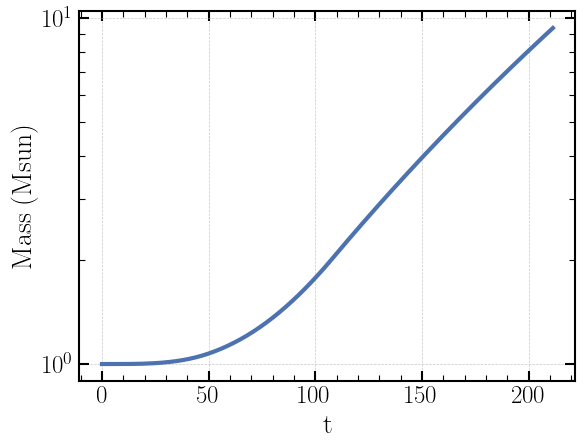

In [31]:
fc = FallingCloud(d0=40.,r_cl0=300.)
fc.integrate(4,stop_mode='height')
#fc.integrate(150)
fc.plot_trajectory()


In [32]:
def strat_n(r):
    n0 = 1
    H = 4
    a = 0.001

    return n0 * np.exp(-a * ((1 + (r/a/H)**2)**0.5 -1))

def strat_g(r):
    g0 = 1e-8
    a = 0.001
    H = 4
    return g0 * r/a/H /(1 + (r/a/H)**2)**0.5 

def strat_T(r):
    return np.ones_like(r) * 1e6

In [33]:

class StratFallingCloud(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, profile = 'MW'):
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        if profile == 'MW':
            self.profile_n = strat_n     # cm^-3
            self.profile_g = strat_g     # (same units used elsewhere)
            self.profile_T = strat_T      # K
            
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s')
        Lturb = r_cl0
        f_A = 0.23
        self.tgrow0 = 30 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25)
        print("This is tgrow: ", self.tgrow0)

    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d):
        return self.r_cl0 * (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)


    def integrate(self,stop_value, f_KH = 1., alpha = 5/6., verbose = 1, stop_mode = 'time'):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                             'time' for stopping time in Myr
                             'height' for falling until height (in kpc) above disk
                             'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """
        def _odefun(t, y):
            # separate variables        
            z, v, m = y
            z_kpc = z / u.kpc.to('m') 
            rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)
            g = -self.profile_g(z_kpc) * 1e-2  
            C0 = 0.6 # drag coefficient
            rcl = self.rcl(z_kpc) 
            rcl_m = rcl * u.parsec.to('m')
            Across = np.pi * rcl_m**2 


            r_pc_to_kpc = u.parsec.to('kpc')
            w_KH = max(1, f_KH* np.sqrt(self.chi(z_kpc)) *
              (self.r_cl0 * r_pc_to_kpc) /
              abs(self.d0 - z_kpc))


            tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s')
            vrat = 150. / min(abs(v)/1000., 150.) 
            tcoolrat = tcool_cl / self.tcool0
            mrat = m  / (self.mass0 * u.Msun.to('kg'))
            rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

            tgrow = w_KH * self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)

            dzdt = v
            dvdt = g - (v / tgrow) + 0.5 * rho_h * v**2 * C0 * Across / m 
            dmdt = m / tgrow
            r = [dzdt, dvdt, dmdt]

            return np.array(r) 
        
        y0 = (self.d0 * u.kpc.to('m'), 1e-3, self.mass0 * u.M_sun.to('kg'))

        tol = (1e-5 * u.kpc.to('m'), 1e-5, 1e-5 * self.mass0* u.M_sun.to('kg'))
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o)
        if verbose > 0:
            print(r['message'])

        self.integration_result = r
        return r
    
    def vTgrow(self, z,v,m, alpha=5/6):
        z_kpc = z / u.kpc.to('m')
        w_KH = np.maximum(1, 5*  np.sqrt(self.chi(z_kpc)) *
            (self.r_cl0 * u.parsec.to('kpc')) /
            abs(self.d0 - z_kpc))


        tcool_cl = get_t_cool_n( self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s') 
        vrat = 150. / np.minimum(abs(v)/1000., 150.) 
        tcoolrat = tcool_cl / self.tcool0
        mrat = m  / (self.mass0 * u.M_sun.to('kg'))
        rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

        tgrow =  w_KH * self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)
        print("this is g: " , self.profile_g)
        return self.profile_g(z_kpc) * tgrow / 1e2
    
    def vTdrag(self, z,m):
        z_kpc = z / u.kpc.to('m')
        rcl = self.rcl(z_kpc) * u.pc.to('m')  # Also fix: use z_kpc
        rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)  # Convert to kg/m³
        return np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * rcl**2 * 0.6))
        #return np.ones_like(z) * np.sqrt(2 * rcl * self.chi(z_kpc) * self.profile_g(z_kpc) * 1e-2 / ( 0.6))

    def plot_trajectory(self):
        assert self.integration_result is not None, "Have to run integrate first."
        r = self.integration_result
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, r['y'][0] / u.kpc.to('m'),'-')
        plt.xlabel("t")
        plt.ylabel("z")
        plt.figure()
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(1,1e3)
        plt.plot(r['t'] / Myr, self.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.yscale('log')
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("Mass (Msun)")


    def plot_timescales(self):
        r = self.integration_result
        time = r['t'][::-1] / u.Myr.to('s')
        plt.plot(time, self.vTgrow(r['y'][0], r['y'][1], r['y'][2]))
        plt.axhline(4, c='black', alpha = 0.5)
        plt.xlabel("t (Myr)")
        plt.ylabel("tgrow / tcc")

This is tgrow:  160.0283706295809
A termination event occurred.
this is g:  <function strat_g at 0x146d653c7c40>


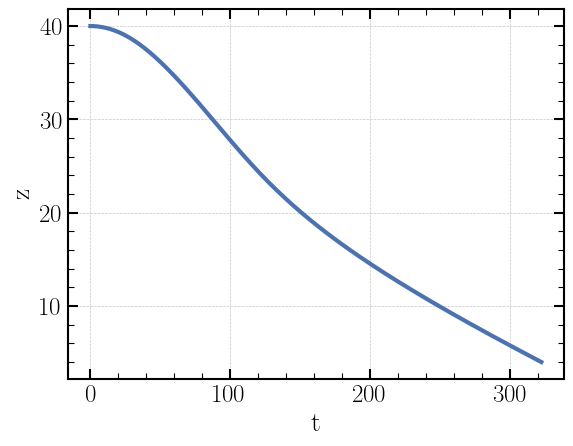

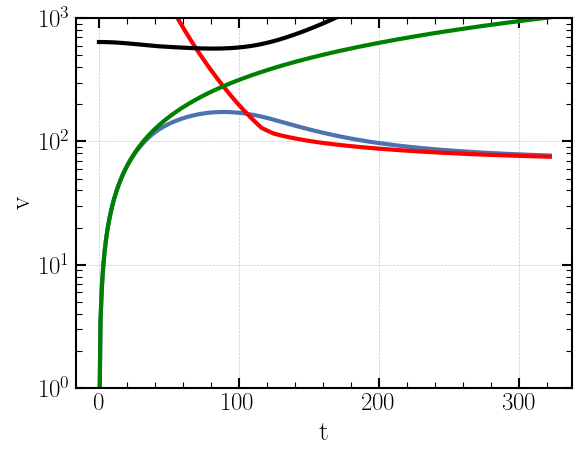

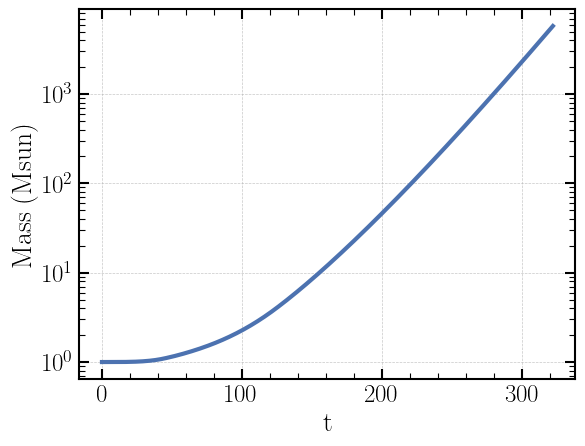

In [34]:
fc = StratFallingCloud(d0=40.,r_cl0=300.)
fc.integrate(4,stop_mode='height')
#fc.integrate(150)
fc.plot_trajectory()

In [91]:

class StratFallingCloud2(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, profile = 'MW', tcool=None):
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        if profile == 'MW':
            self.profile_n = strat_n     # cm^-3
            self.profile_g = strat_g     # (same units used elsewhere)
            self.profile_T = strat_T      # K
        
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        if tcool == None:  
            self.Lambda_units = 1
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s')
        else:
            self.Lambda_units = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s') / tcool
            self.tcool0 = tcool
        Lturb = r_cl0
        f_A = 0.23
        self.tgrow0 = 35 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25)
        print("This is tgrow: ", self.tgrow0)

    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d):
        return self.r_cl0 * (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)


    def integrate(self,stop_value, f_KH = 1., alpha = 5/6., verbose = 1, stop_mode = 'time'):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                             'time' for stopping time in Myr
                             'height' for falling until height (in kpc) above disk
                             'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """
        def _odefun(t, y):
            # separate variables        
            z, v, m = y
            z_kpc = z / u.kpc.to('m') 
            rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)
            g = -self.profile_g(z_kpc) * 1e-2  
            C0 = 0.6 # drag coefficient
            rcl = self.rcl(z_kpc) 
            rcl_m = rcl * u.parsec.to('m')
            Across = np.pi * rcl_m**2 


            r_pc_to_kpc = u.parsec.to('kpc')
            w_KH = max(1, f_KH* np.sqrt(self.chi(z_kpc)) *
              (self.r_cl0 * r_pc_to_kpc) /
              abs(self.d0 - z_kpc))


            tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s')  / self.Lambda_units
            vrat = 150. / min(abs(v)/1000., 150.) 
            tcoolrat = tcool_cl / self.tcool0
            mrat = m  / (self.mass0 * u.Msun.to('kg'))
            rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

            tgrow = w_KH * self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)

            dzdt = v
            dvdt = g - (v / tgrow) + 0.5 * rho_h * v**2 * C0 * Across / m 
            dmdt = m / tgrow
            r = [dzdt, dvdt, dmdt]

            return np.array(r) 
        
        y0 = (self.d0 * u.kpc.to('m'), 1e-3, self.mass0 * u.M_sun.to('kg'))

        tol = (1e-5 * u.kpc.to('m'), 1e-5, 1e-5 * self.mass0* u.M_sun.to('kg'))
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o)
        if verbose > 0:
            print(r['message'])

        self.integration_result = r
        return r
    
    def vTgrow(self, z,v,m, f_KH = 1, alpha=5/6):
        z_kpc = z / u.kpc.to('m')
        w_KH = np.maximum(1,  f_KH *np.sqrt(self.chi(z_kpc)) *
            (self.r_cl0 * u.parsec.to('kpc')) /
            abs(self.d0 - z_kpc))


        tcool_cl = get_t_cool_n( self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s')  / self.Lambda_units
        vrat = 150. / np.minimum(abs(v)/1000., 150.) 
        tcoolrat = tcool_cl / self.tcool0
        mrat = m  / (self.mass0 * u.M_sun.to('kg'))
        rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

        tgrow =  w_KH * self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)
        print("this is g: " , self.profile_g)
        return self.profile_g(z_kpc) * tgrow / 1e2
    
    def vTdrag(self, z,m):
        z_kpc = z / u.kpc.to('m')
        rcl = self.rcl(z_kpc) * u.pc.to('m')  # Also fix: use z_kpc
        rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)  # Convert to kg/m³
        return np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * rcl**2 * 0.6))
        #return np.ones_like(z) * np.sqrt(2 * rcl * self.chi(z_kpc) * self.profile_g(z_kpc) * 1e-2 / ( 0.6))

    def plot_trajectory(self):
        assert self.integration_result is not None, "Have to run integrate first."
        r = self.integration_result
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, r['y'][0] / u.kpc.to('m'),'-')
        plt.xlabel("t")
        plt.ylabel("z")
        plt.figure()
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(1,1e3)
        plt.plot(r['t'] / Myr, self.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.yscale('log')
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("Mass (Msun)")


    def plot_timescales(self):
        r = self.integration_result
        time = r['t'][::-1] / u.Myr.to('s')
        plt.plot(time, self.vTgrow(r['y'][0], r['y'][1], r['y'][2]))
        plt.axhline(4, c='black', alpha = 0.5)
        plt.xlabel("t (Myr)")
        plt.ylabel("tgrow / tcc")

In [94]:
from stratified_box import StratifiedBox
import os
from flow_props import mass_evolution, vel_evolution


class CompareRuns(object):

    def __init__(self, r_cl0, rundir, T_cl = 1e4, profile = 'MW', tcool = None):

        self.rundir = rundir
        self.sim = StratifiedBox(os.path.join(self.rundir, 'strat.in'), dir=self.rundir)
        self.cloud = StratFallingCloud2(self.sim.y_centre/1e3, r_cl0, T_cl, profile=profile, tcool=tcool)
        self.rundir = rundir
                # Load simulation


    def compare_plots(self, item, stop_mode='time'):
        
        r = self.cloud.integrate(item, stop_mode=stop_mode)


        times, norm_mass, cgout, wgout, total = mass_evolution(self.rundir, gout=True)
        tvs, vel = vel_evolution(self.rundir)
        mask = ~np.isnan(norm_mass)
        timeseries = times/self.sim.t_eddy - 6
        idx_0 = np.argmin(np.abs(timeseries))
        norm_mass = norm_mass- norm_mass[idx_0]

        timeseries = timeseries[mask] * self.sim.t_eddy * self.sim.code_time_cgs / u.Myr.to('s')
        norm_mass = 10**norm_mass[mask]

        # Plot with integrated results
        plt.style.use('custom_plot')
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(-10,100)
        plt.plot(r['t'] / Myr, self.cloud.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.cloud.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.plot(timeseries, vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e5, alpha = 0.8, label='sim')
        #plt.yscale('log')
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.scatter(timeseries, norm_mass, alpha=0.8, label='sim', color='orange')
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("m / m0")



class CompareRunsNoTurb(object):

    def __init__(self, r_cl0, rundir, T_cl = 1e4, profile = 'MW', tcool = None):

        self.rundir = rundir
        self.sim = StratifiedBox(os.path.join(self.rundir, 'strat.in'), dir=self.rundir)
        self.cloud = StratFallingCloud2(self.sim.y_centre/1e3, r_cl0, T_cl, profile=profile, tcool=tcool)
        self.rundir = rundir
                # Load simulation


    def compare_plots(self, item, stop_mode='time', f_KH = 3):
        
        r = self.cloud.integrate(item, stop_mode=stop_mode, f_KH=f_KH)


        times, norm_mass, cgout, wgout, total = mass_evolution(self.rundir, gout=True)
        tvs, vel = vel_evolution(self.rundir)
        mask = ~np.isnan(norm_mass)
        timeseries = times[mask]
        idx_0 = np.argmin(np.abs(timeseries))
        norm_mass = norm_mass- norm_mass[idx_0]

        timeseries = timeseries[mask] *  self.sim.code_time_cgs / u.Myr.to('s')
        norm_mass = 10**norm_mass[mask]

        # Plot with integrated results
        plt.style.use('custom_plot')
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(-10,100)
        plt.plot(r['t'] / Myr, self.cloud.vTgrow(r['y'][0], r['y'][1], r['y'][2], f_KH=f_KH)/1e3, color='red')
        plt.plot(r['t'] / Myr, self.cloud.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.plot(timeseries, vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e5, alpha = 0.8, label='sim')
        #plt.yscale('log')
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.scatter(timeseries, norm_mass, alpha=0.8, label='sim', color='orange')
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("m / m0")

This is tgrow:  7.401598844083948
The solver successfully reached the end of the integration interval.
this is g:  <function strat_g at 0x146d653c7c40>


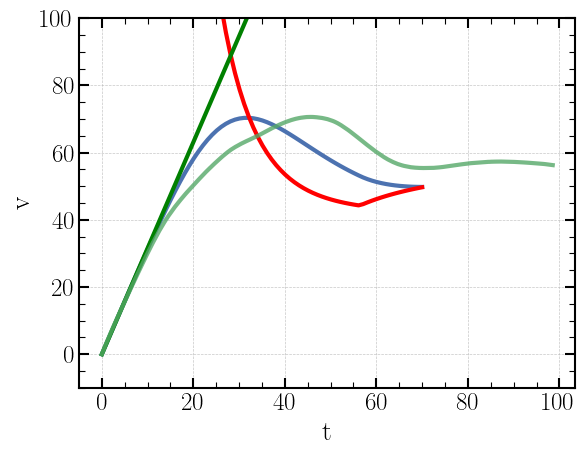

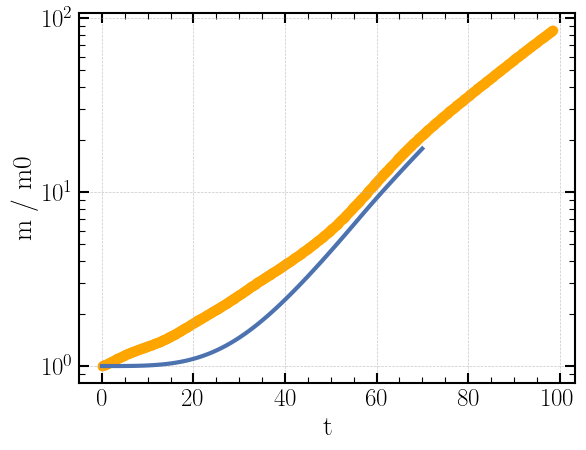

In [103]:
fc = CompareRunsNoTurb(r_cl0=100, tcool = 6e-5, rundir='/viper/ptmp/ferhi/StratDisk/noturb/r100')
fc.compare_plots(70, f_KH=3)

this is tff:,  44.25286237443971
This is tgrow:  5.202683402375513
The solver successfully reached the end of the integration interval.
this is g:  <function strat_g at 0x146d6e304540>


/tmp/ipykernel_2791299/2885013365.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = max(1, f_KH* np.sqrt(self.chi(z_kpc)) *
/tmp/ipykernel_2791299/2885013365.py:120: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, 5*  np.sqrt(self.chi(z_kpc)) *


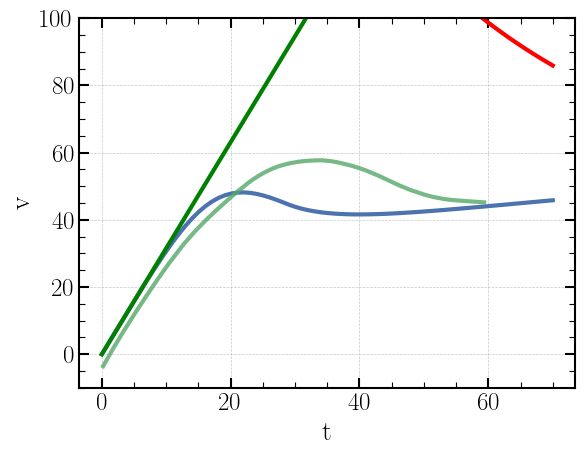

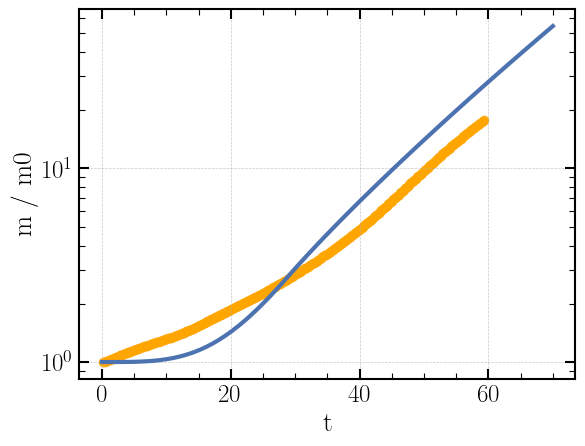

In [29]:
fc = CompareRuns(r_cl0=100, tcool = 1.06e-3, rundir='/viper/ptmp/ferhi/StratDisk/OldRuns/Rsys/m0.1/r100/t1e4')
fc.compare_plots(70)

This is tgrow:  16.452329496260898
The solver successfully reached the end of the integration interval.
this is g:  <function strat_g at 0x14e8d62f9940>


/tmp/ipykernel_1432169/2885013365.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = max(1, f_KH* np.sqrt(self.chi(z_kpc)) *
/tmp/ipykernel_1432169/2885013365.py:120: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, 5*  np.sqrt(self.chi(z_kpc)) *


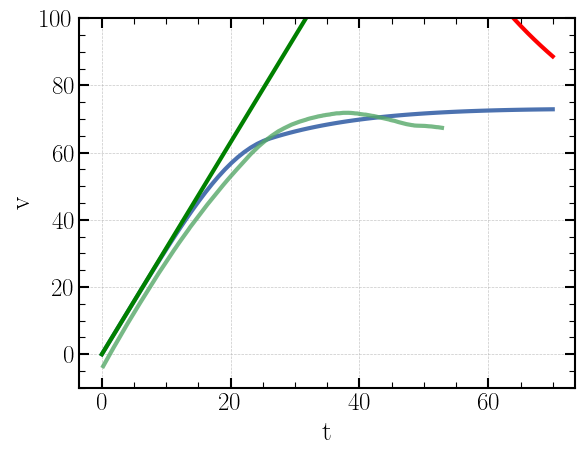

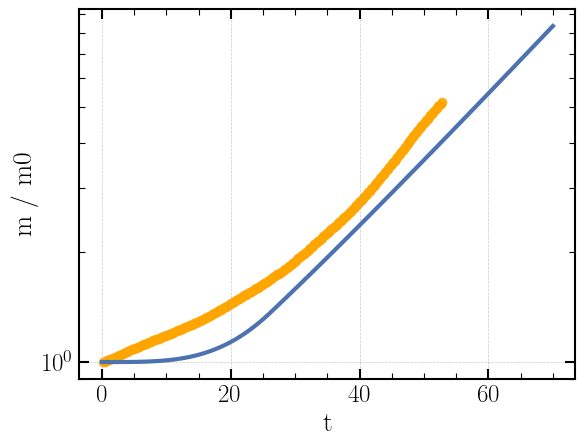

In [17]:
fc = CompareRuns(r_cl0=100, tcool = 1.06e-1, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r100/t1e6')
fc.compare_plots(70)